# **Solar_power_generation– Exploratory Data Analysis (EDA)**
### **Project: Solar_power_generation**
### **Dataset Size: 2920 Instances**



In [50]:
# Basic libraries
import pandas as pd
import numpy as np

In [51]:
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv(r"solarpowergeneration.csv")
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


## **Basic Understanding of the Dataset**
We start by checking:
- First few rows  
- Shape  
- Column names  
- Data types  
- Missing values  

In [53]:
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [54]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (2920, 10)


In [55]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed', 'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)', 'average-pressure-(period)', 'power-generated']


In [56]:
print("\nData Types:")
print(df.dtypes)


Data Types:
distance-to-solar-noon         float64
temperature                      int64
wind-direction                   int64
wind-speed                     float64
sky-cover                        int64
visibility                     float64
humidity                         int64
average-wind-speed-(period)    float64
average-pressure-(period)      float64
power-generated                  int64
dtype: object


In [57]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    1
average-pressure-(period)      0
power-generated                0
dtype: int64


In [58]:
df.describe()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.261547,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


**Target Variable Distribution**

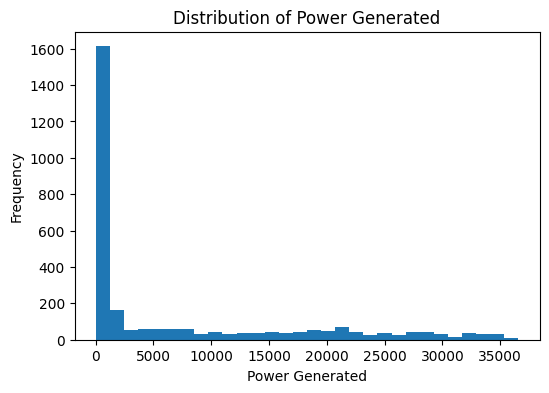

In [59]:

plt.figure(figsize=(6,4))
plt.hist(df['power-generated'], bins=30)
plt.title("Distribution of Power Generated")
plt.xlabel("Power Generated")
plt.ylabel("Frequency")
plt.show()

In [60]:
df.drop(columns=["visibility","average-pressure-(period)","average-wind-speed-(period)"],inplace=True)

In [61]:
df['wind-speed'].fillna(df['wind-speed'].median(), inplace=True)


C:\Users\Dell\AppData\Local\Temp\ipykernel_9448\1379296528.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['wind-speed'].fillna(df['wind-speed'].median(), inplace=True)


Filling the 1 missing value in wind speed to prevent gaps in the plots

## Univariate Analysis (Numerical Variables)

We visualize the distribution of each numerical column using histograms.

In [62]:
numerical_cols = list(df.select_dtypes(include=['float64']).columns)

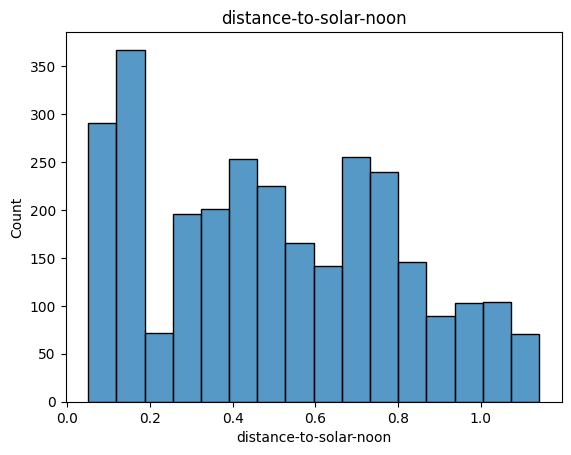

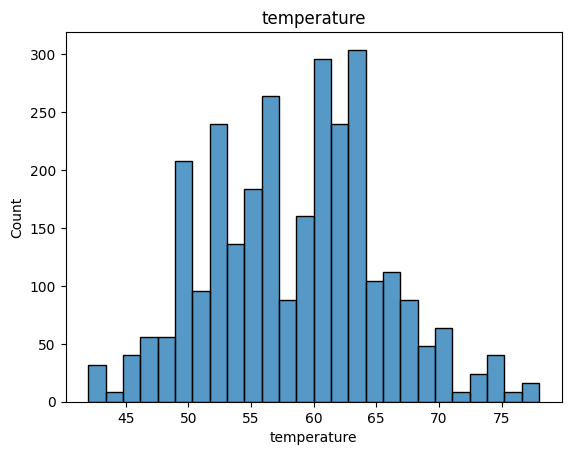

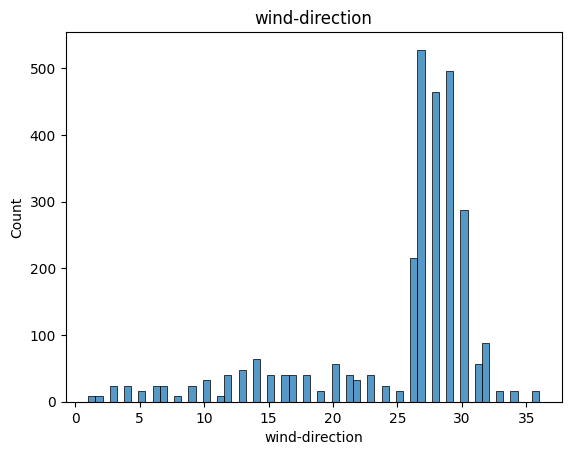

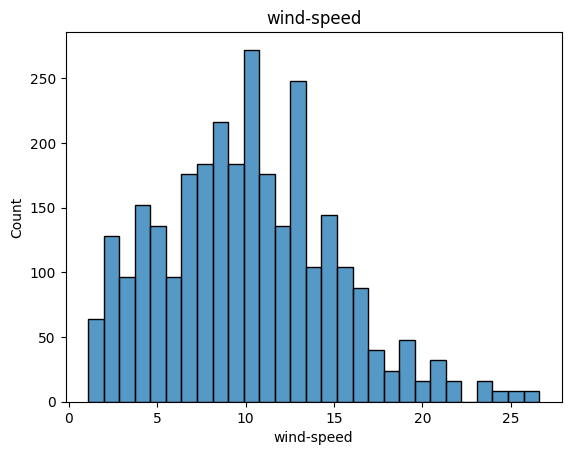

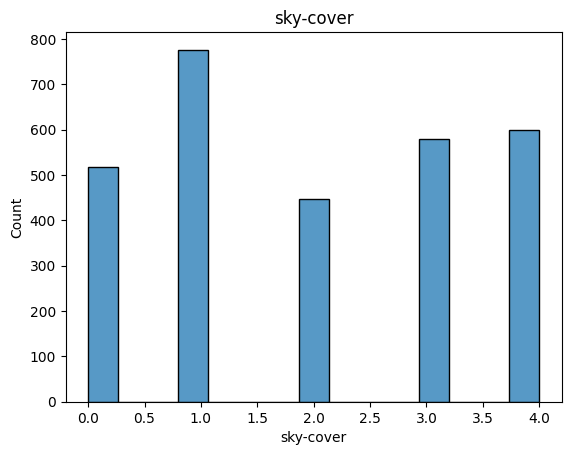

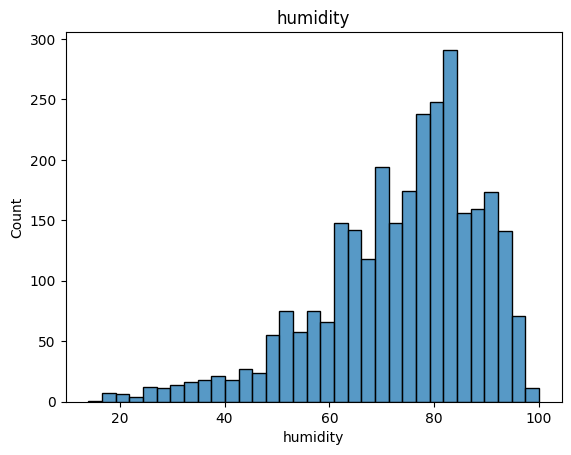

In [63]:
num_cols = df.columns.drop('power-generated')

for col in num_cols:
    sns.histplot(x=df[col])
    plt.title(col)
    plt.show()


##  Bivariate Analysis (Numerical Feature vs power-generated)



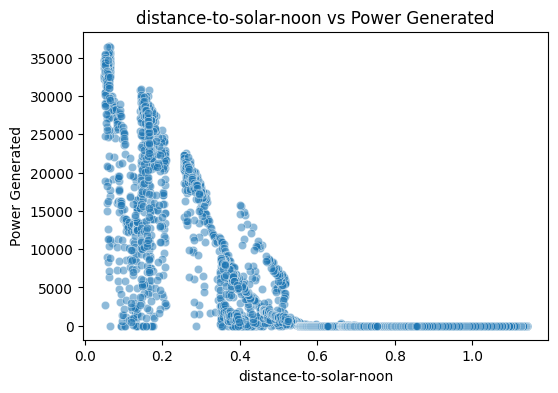

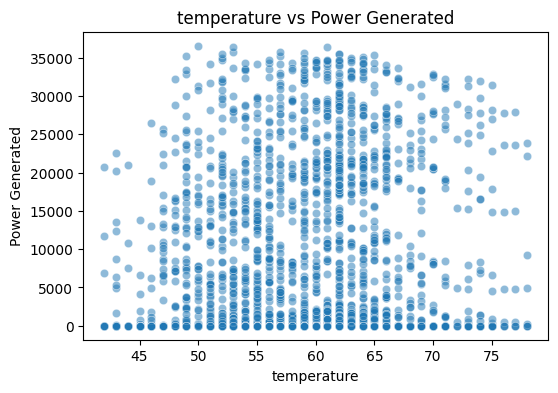

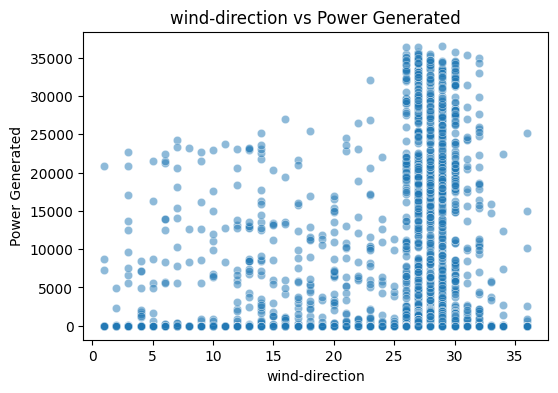

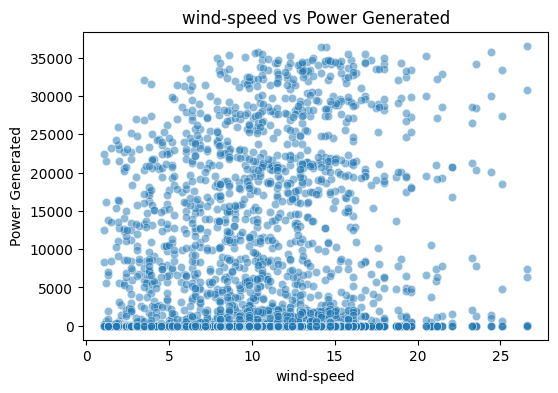

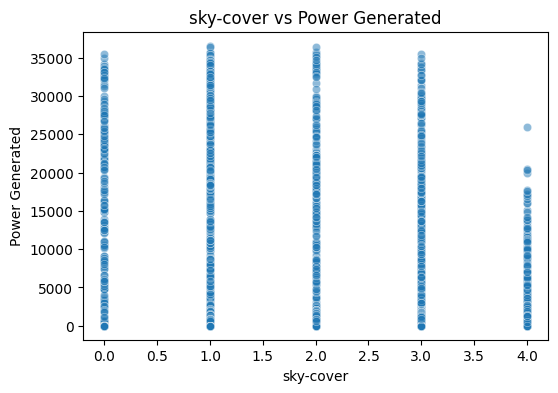

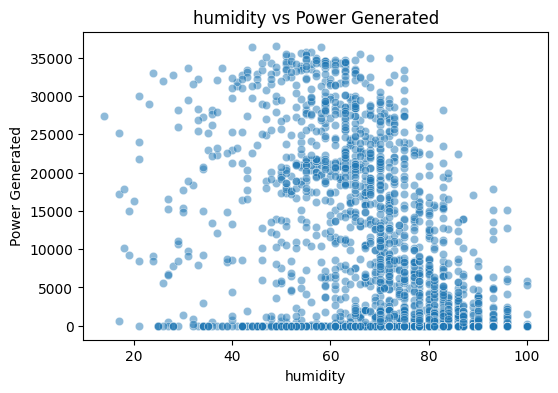

In [64]:

for col in num_cols:
    if col != 'power-generated':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df['power-generated'], alpha=0.5)
        plt.title(f"{col} vs Power Generated")
        plt.xlabel(col)
        plt.ylabel("Power Generated")
        plt.show()


# Correlation Analysis

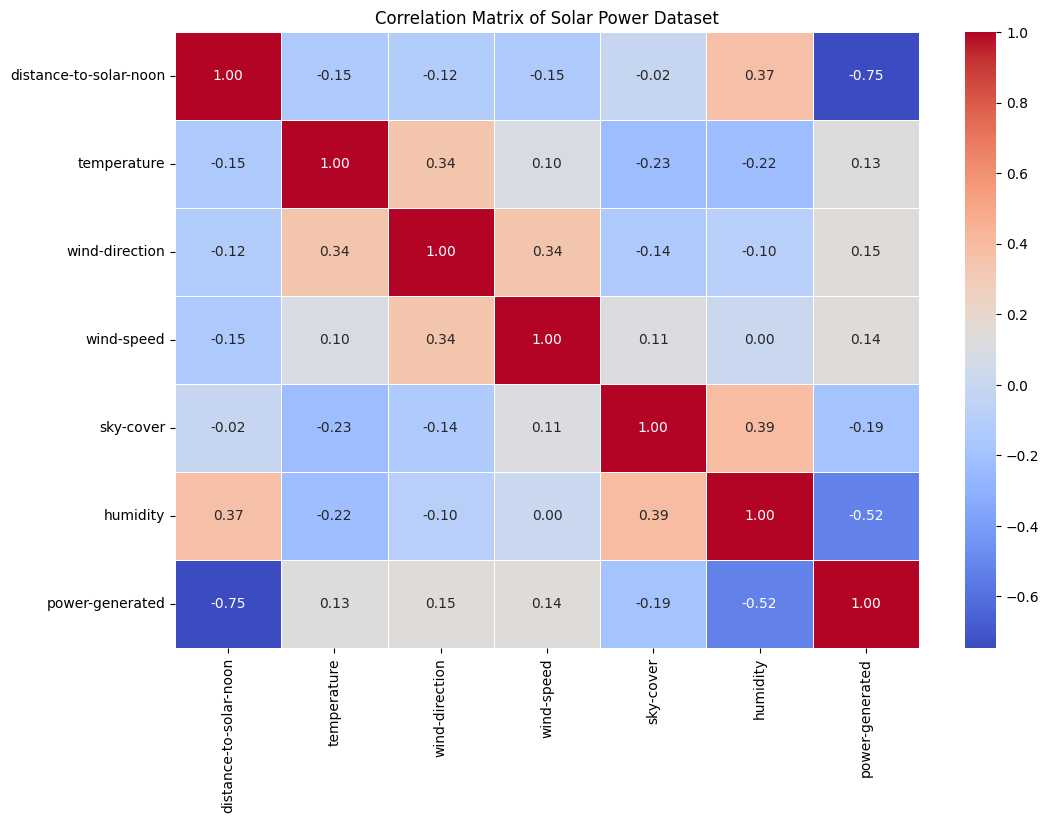

In [65]:
plt.figure(figsize=(12,8))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Solar Power Dataset")
plt.show()


In [66]:
df.skew()

distance-to-solar-noon    0.211452
temperature               0.125916
wind-direction           -1.629519
wind-speed                0.416851
sky-cover                 0.080284
humidity                 -0.955607
power-generated           1.307035
dtype: float64

Checking for outliers 

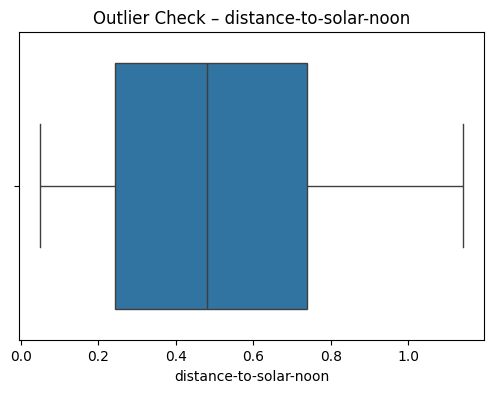

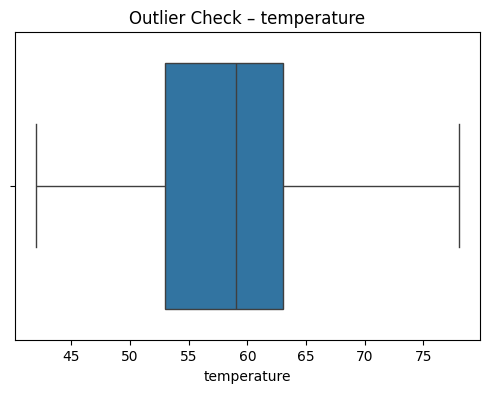

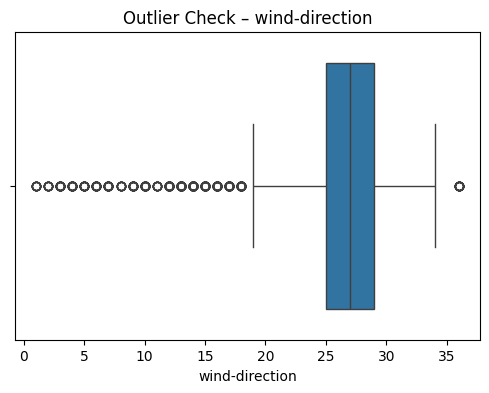

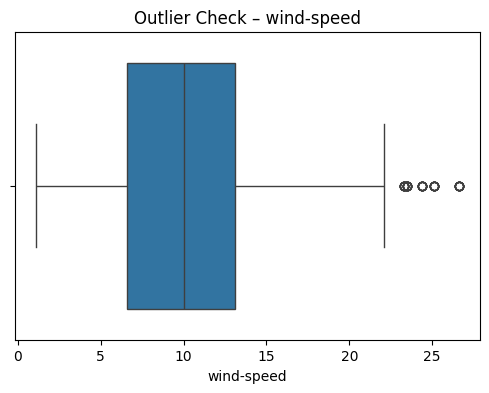

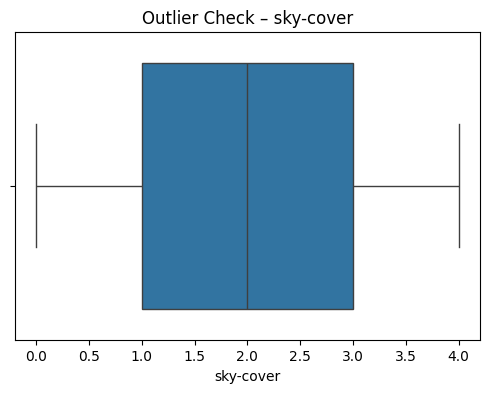

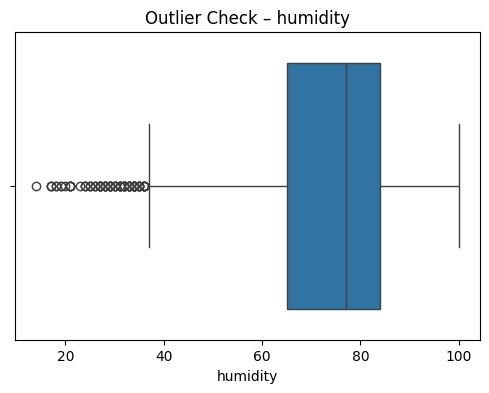

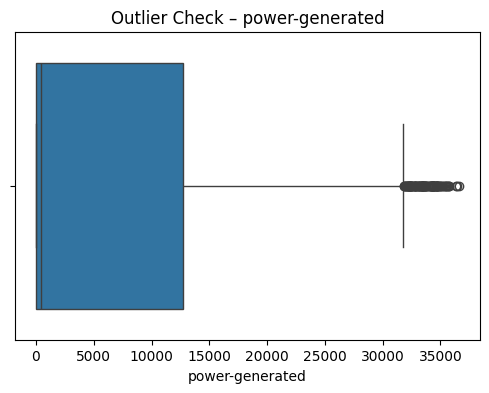

In [67]:
for col in df:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Check – {col}")
    plt.show()

**Important Feature Patterns**

In [68]:
corr = df.corr()['power-generated'].sort_values(ascending=False)
print(corr)


power-generated           1.000000
wind-direction            0.146788
wind-speed                0.142641
temperature               0.132193
sky-cover                -0.187236
humidity                 -0.522545
distance-to-solar-noon   -0.746681
Name: power-generated, dtype: float64


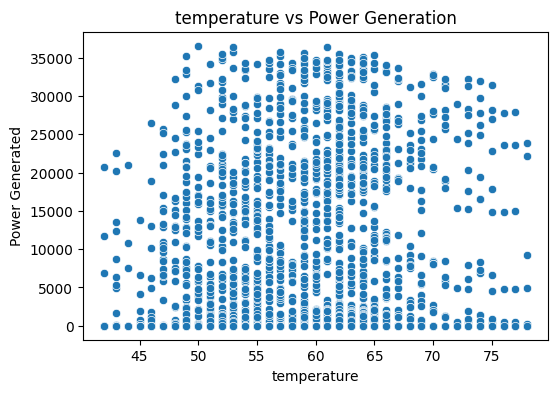

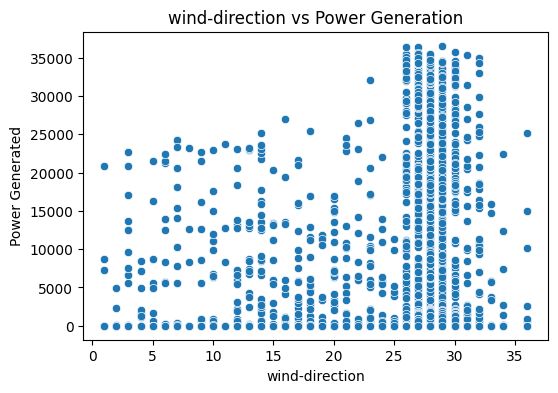

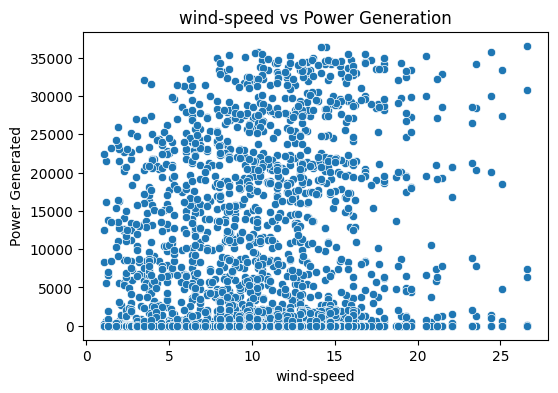

In [74]:
important_vars = [
    'temperature',
    'wind-direction',
    'wind-speed'
]

for col in important_vars:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['power-generated'])
    plt.title(f"{col} vs Power Generation")
    plt.xlabel(col)
    plt.ylabel("Power Generated")
    plt.show()


In [77]:
df.corr()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,humidity,power-generated
distance-to-solar-noon,1.000000,-0.145207,-0.118010,-0.145073,-0.015184,0.368964,-0.746681
temperature,-0.145207,1.000000,0.342146,0.096267,-0.230672,-0.221463,0.132193
wind-direction,-0.118010,0.342146,1.000000,0.341529,-0.137140,-0.095917,0.146788
wind-speed,-0.145073,0.096267,0.341529,1.000000,0.107793,0.004901,0.142641
sky-cover,-0.015184,-0.230672,-0.137140,0.107793,1.000000,0.394576,-0.187236
humidity,0.368964,-0.221463,-0.095917,0.004901,0.394576,1.000000,-0.522545
power-generated,-0.746681,0.132193,0.146788,0.142641,-0.187236,-0.522545,1.000000


In [78]:
data=df.corr()
print(data.loc["power-generated"].nlargest(5))
print("\n")
print(data.loc["power-generated"].nsmallest(5))


power-generated    1.000000
wind-direction     0.146788
wind-speed         0.142641
temperature        0.132193
sky-cover         -0.187236
Name: power-generated, dtype: float64


distance-to-solar-noon   -0.746681
humidity                 -0.522545
sky-cover                -0.187236
temperature               0.132193
wind-speed                0.142641
Name: power-generated, dtype: float64


In [79]:
data.loc[data.loc["power-generated"].nlargest(5).index]

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,humidity,power-generated
power-generated,-0.746681,0.132193,0.146788,0.142641,-0.187236,-0.522545,1.000000
wind-direction,-0.118010,0.342146,1.000000,0.341529,-0.137140,-0.095917,0.146788
wind-speed,-0.145073,0.096267,0.341529,1.000000,0.107793,0.004901,0.142641
temperature,-0.145207,1.000000,0.342146,0.096267,-0.230672,-0.221463,0.132193
sky-cover,-0.015184,-0.230672,-0.137140,0.107793,1.000000,0.394576,-0.187236


In [80]:
data.loc[data.loc["power-generated"].nsmallest(5).index]

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,humidity,power-generated
distance-to-solar-noon,1.000000,-0.145207,-0.118010,-0.145073,-0.015184,0.368964,-0.746681
humidity,0.368964,-0.221463,-0.095917,0.004901,0.394576,1.000000,-0.522545
sky-cover,-0.015184,-0.230672,-0.137140,0.107793,1.000000,0.394576,-0.187236
temperature,-0.145207,1.000000,0.342146,0.096267,-0.230672,-0.221463,0.132193
wind-speed,-0.145073,0.096267,0.341529,1.000000,0.107793,0.004901,0.142641


#EDA–1: Standard Scaler + One-Hot Encoding

In [81]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [82]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [83]:
st=StandardScaler()
starray=st.fit_transform(df[numerical_cols])
st_df=pd.DataFrame(starray,columns=st.get_feature_names_out())


In [84]:
st_df

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,humidity,power-generated
0,1.196765,1.539688,0.440639,-0.536861,-1.407962,0.098597,-0.676960
1,0.420310,1.539688,0.440639,-0.536861,-1.407962,0.231271,-0.676960
2,-0.356146,1.539688,0.440639,-0.536861,-1.407962,-0.233088,-0.151480
3,-1.132602,1.539688,0.440639,-0.536861,-1.407962,-2.687555,1.793999
4,-1.469066,1.539688,0.440639,-0.536861,-1.407962,-3.483598,2.239367
...,...,...,...,...,...,...,...
2915,-1.130442,0.662498,0.296005,0.786176,1.425428,0.098597,0.001470
2916,-1.474208,0.662498,0.296005,0.786176,-0.699615,-0.498436,2.183211
2917,-0.700735,0.662498,0.296005,0.786176,0.008733,-0.365762,0.996759
2918,0.072738,0.662498,0.296005,0.786176,0.008733,0.496618,-0.611299


#ONE-HOT ENCODING